# Домашнее задание HW07: Кластеризация

## Цель работы
### Закрепить навыки применения различных методов кластеризации, оценки их качества и проведения "честного" unsupervised-эксперимента.

# 1. Импорт библиотек

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.stats import gaussian_kde
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создаем директории для артефактов
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
labels_dir = artifacts_dir / "labels"

for dir_path in [artifacts_dir, figures_dir, labels_dir]:
    dir_path.mkdir(exist_ok=True, parents=True)

# 2. Вспомогательные функции

In [17]:
def visualize_raw_data(X, dataset_name):
    """Визуализация исходных данных в 2D перед кластеризацией"""
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter plot
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], s=20, alpha=0.6)
    axes[0].set_title(f'{dataset_name}: PCA проекция (сырые данные)')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    axes[0].grid(True, alpha=0.3)
    
    # KDE plot для оценки плотности
    kde = gaussian_kde(X_pca.T)
    x_grid, y_grid = np.mgrid[X_pca[:, 0].min():X_pca[:, 0].max():100j, 
                             X_pca[:, 1].min():X_pca[:, 1].max():100j]
    grid_coords = np.vstack([x_grid.ravel(), y_grid.ravel()])
    z = kde(grid_coords).reshape(x_grid.shape)
    
    axes[1].contourf(x_grid, y_grid, z, levels=20, cmap='viridis')
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.5, color='white')
    axes[1].set_title(f'{dataset_name}: Контуры плотности')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    
    plt.tight_layout()
    plt.savefig(figures_dir / f'{dataset_name}_raw_visualization.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return X_pca, pca.explained_variance_ratio_

def evaluate_clustering(X, labels, model_name=""):
    """Оценка качества кластеризации с учетом шума"""
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1]) if -1 in unique_labels else len(unique_labels)
    noise_ratio = np.mean(labels == -1) if -1 in labels else 0.0
    
    metrics = {
        'n_clusters': n_clusters,
        'noise_ratio': float(noise_ratio),
        'silhouette': None,
        'davies_bouldin': None,
        'calinski_harabasz': None
    }
    
    # Считаем метрики только если есть хотя бы 2 кластера
    if n_clusters >= 2:
        mask = labels != -1 if -1 in labels else slice(None)
        X_masked = X[mask] if isinstance(mask, np.ndarray) else X
        labels_masked = labels[mask] if isinstance(mask, np.ndarray) else labels
        
        if len(np.unique(labels_masked)) >= 2:
            try:
                metrics['silhouette'] = float(silhouette_score(X_masked, labels_masked))
                metrics['davies_bouldin'] = float(davies_bouldin_score(X_masked, labels_masked))
                metrics['calinski_harabasz'] = float(calinski_harabasz_score(X_masked, labels_masked))
            except:
                pass
    
    return metrics

def plot_clustering_results(X, labels_list, titles, dataset_name, figsize=(15, 5)):
    """Визуализация результатов кластеризации"""
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    n_plots = len(labels_list)
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]
    
    for i, (ax, labels, title) in enumerate(zip(axes, labels_list, titles)):
        if -1 in labels:
            # Рисуем шум отдельно
            noise_mask = labels == -1
            ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                      c='gray', s=10, alpha=0.3, label='Шум')
            cluster_mask = labels != -1
            scatter = ax.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                                c=labels[cluster_mask], s=20, cmap='tab20', label='Кластеры')
            if i == 0:
                ax.legend()
        else:
            scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20, cmap='tab20')
        
        ax.set_title(f'{title}\nКластеров: {len(np.unique(labels[labels != -1])) if -1 in labels else len(np.unique(labels))}')
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / f'{dataset_name}_clustering_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return X_pca

def plot_elbow_method(X, k_range, dataset_name):
    """График elbow method для KMeans"""
    inertias = []
    silhouettes = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        
        if k > 1:
            silhouettes.append(silhouette_score(X, labels))
        else:
            silhouettes.append(0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(k_range, inertias, 'bo-')
    axes[0].set_xlabel('Число кластеров (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'{dataset_name}: Elbow Method (Inertia)')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(k_range[1:], silhouettes[1:], 'ro-')
    axes[1].set_xlabel('Число кластеров (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'{dataset_name}: Silhouette Score vs k')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / f'{dataset_name}_elbow_method.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return inertias, silhouettes

def plot_dendrogram(X, dataset_name, method='ward'):
    """Построение дендрограммы для иерархической кластеризации"""
    plt.figure(figsize=(10, 6))
    
    # Берем подвыборку для читаемости дендрограммы
    n_samples = min(100, len(X))
    indices = np.random.choice(len(X), n_samples, replace=False)
    X_sample = X[indices]
    
    Z = scipy_linkage(X_sample, method=method)
    
    dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True)
    plt.title(f'{dataset_name}: Дендрограмма (linkage={method})')
    plt.xlabel('Номер точки')
    plt.ylabel('Расстояние')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / f'{dataset_name}_dendrogram.png', dpi=100, bbox_inches='tight')
    plt.show()

# 3. Загрузка данных

In [19]:
# Загружаем 3 датасета
datasets = {}
for i in [1, 2, 3]:
    file_name = f"S07-hw-dataset-0{i}.csv"
    if os.path.exists(file_name):
        datasets[f"ds{i}"] = pd.read_csv(file_name)
        print(f"Загружен датасет {i}: {len(datasets[f'ds{i}'])} строк, {len(datasets[f'ds{i}'].columns)} столбцов")
    else:
        print(f"Внимание: файл {file_name} не найден")

Загружен датасет 1: 12000 строк, 9 столбцов
Загружен датасет 2: 8000 строк, 4 столбцов
Загружен датасет 3: 15000 строк, 5 столбцов


# 4. Анализ и препроцессинг для каждого датасета

## 4.1 Dataset 1: Числовые признаки в разных шкалах

DATASET 1: Анализ
Размер: (12000, 9)

Первые 5 строк:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB

Статистика (обратите внимание на разные шкалы!):


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



Проверка пропусков:
sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64

Признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Все признаки числовые: True

Визуализация сырых данных Dataset 1:


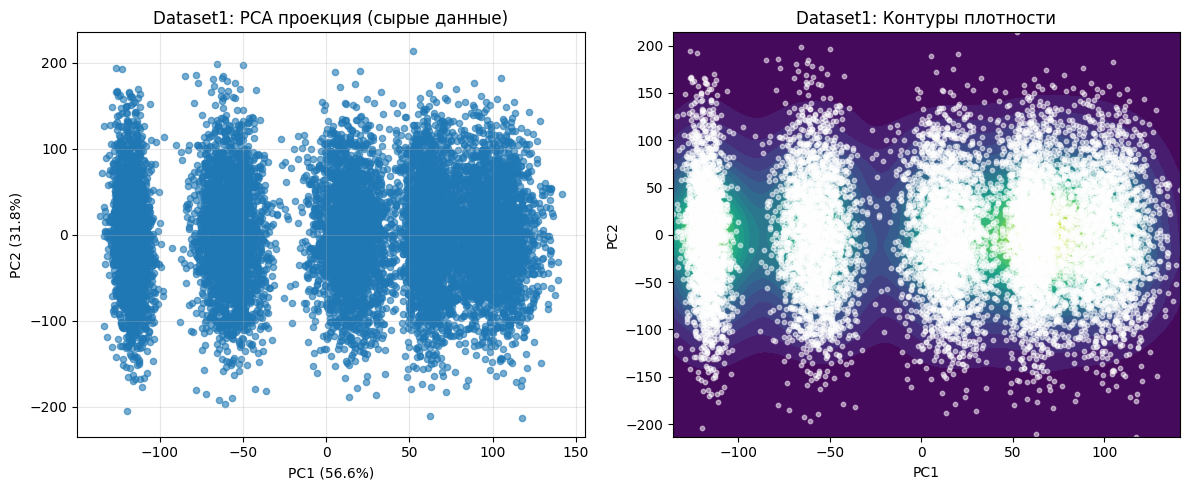

Объясненная дисперсия PCA: 88.4%

После масштабирования:
Средние: [ 0. -0. -0. -0. -0.  0. -0. -0.]
Стандартные отклонения: [1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
print("=" * 80)
print("DATASET 1: Анализ")
print("=" * 80)

ds1 = datasets['ds1']
print(f"Размер: {ds1.shape}")
print("\nПервые 5 строк:")
display(ds1.head())

print("\nИнформация о данных:")
ds1.info()

print("\nСтатистика (обратите внимание на разные шкалы!):")
display(ds1.describe())

print("\nПроверка пропусков:")
print(ds1.isnull().sum())

# Разделяем на признаки и идентификаторы
X1 = ds1.drop('sample_id', axis=1).copy()
sample_ids1 = ds1['sample_id'].copy()

print(f"\nПризнаки: {X1.columns.tolist()}")
print(f"Все признаки числовые: {all(X1.dtypes != 'object')}")

# Визуализация сырых данных
print("\nВизуализация сырых данных Dataset 1:")
X1_pca_raw, var_ratio1 = visualize_raw_data(X1, "Dataset1")
print(f"Объясненная дисперсия PCA: {var_ratio1.sum():.1%}")

# Препроцессинг для dataset 1
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

print(f"\nПосле масштабирования:")
print(f"Средние: {X1_scaled.mean(axis=0).round(2)}")
print(f"Стандартные отклонения: {X1_scaled.std(axis=0).round(2)}")

## 4.2 Dataset 2: Нелинейная структура + выбросы


DATASET 2: Анализ
Размер: (8000, 4)

Первые 5 строк:


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472



Статистика:


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076



Проверка пропусков:
sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64

Признаки: ['x1', 'x2', 'z_noise']

Визуализация сырых данных Dataset 2:


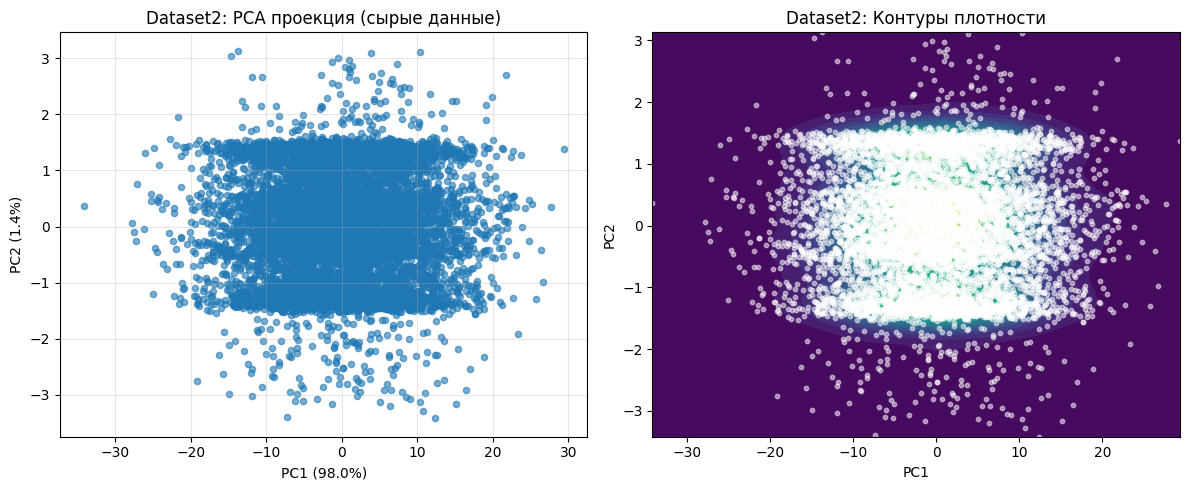

Объясненная дисперсия PCA: 99.4%


In [21]:
print("\n" + "=" * 80)
print("DATASET 2: Анализ")
print("=" * 80)

ds2 = datasets['ds2']
print(f"Размер: {ds2.shape}")
print("\nПервые 5 строк:")
display(ds2.head())

print("\nСтатистика:")
display(ds2.describe())

print("\nПроверка пропусков:")
print(ds2.isnull().sum())

# Разделяем на признаки и идентификаторы
X2 = ds2.drop('sample_id', axis=1).copy()
sample_ids2 = ds2['sample_id'].copy()

print(f"\nПризнаки: {X2.columns.tolist()}")

# Визуализация сырых данных
print("\nВизуализация сырых данных Dataset 2:")
X2_pca_raw, var_ratio2 = visualize_raw_data(X2, "Dataset2")
print(f"Объясненная дисперсия PCA: {var_ratio2.sum():.1%}")

# Препроцессинг для dataset 2
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

## 4.3 Dataset 3: Кластеры разной плотности + шум


DATASET 3: Анализ
Размер: (15000, 5)

Первые 5 строк:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899



Статистика:


,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865



Проверка пропусков:
sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64

Признаки: ['x1', 'x2', 'f_corr', 'f_noise']

Визуализация сырых данных Dataset 3:


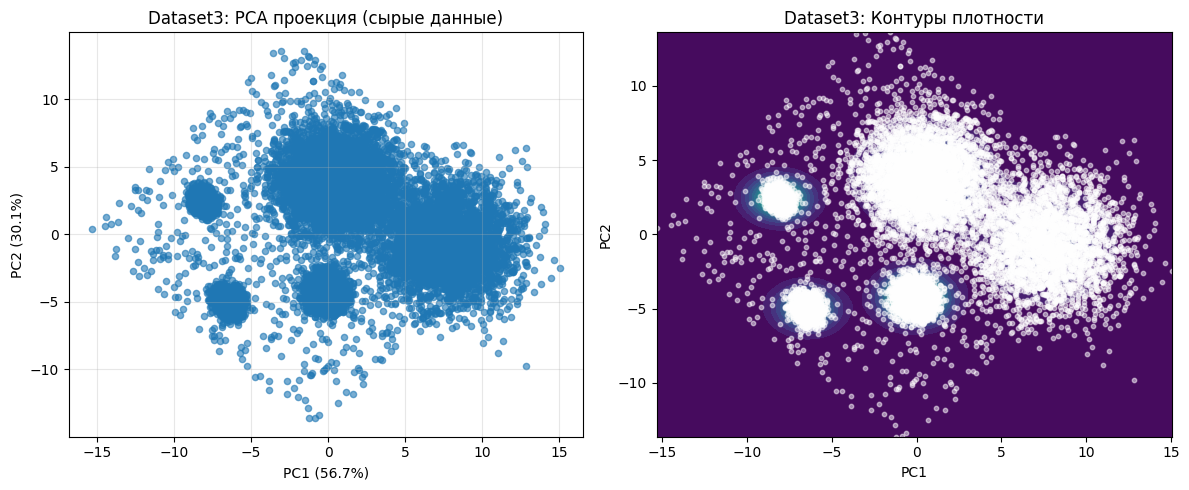

Объясненная дисперсия PCA: 86.8%


In [22]:
print("\n" + "=" * 80)
print("DATASET 3: Анализ")
print("=" * 80)

ds3 = datasets['ds3']
print(f"Размер: {ds3.shape}")
print("\nПервые 5 строк:")
display(ds3.head())

print("\nСтатистика:")
display(ds3.describe())

print("\nПроверка пропусков:")
print(ds3.isnull().sum())

# Разделяем на признаки и идентификаторы
X3 = ds3.drop('sample_id', axis=1).copy()
sample_ids3 = ds3['sample_id'].copy()

print(f"\nПризнаки: {X3.columns.tolist()}")

# Визуализация сырых данных
print("\nВизуализация сырых данных Dataset 3:")
X3_pca_raw, var_ratio3 = visualize_raw_data(X3, "Dataset3")
print(f"Объясненная дисперсия PCA: {var_ratio3.sum():.1%}")

# Препроцессинг для dataset 3
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)


# 5. Кластеризация по датасетам

## 5.1 Dataset 1: KMeans + AgglomerativeClustering

DATASET 1: Кластеризация
Визуальный анализ: видно 3-4 кластера

1. KMeans: подбор k в диапазоне 2-10


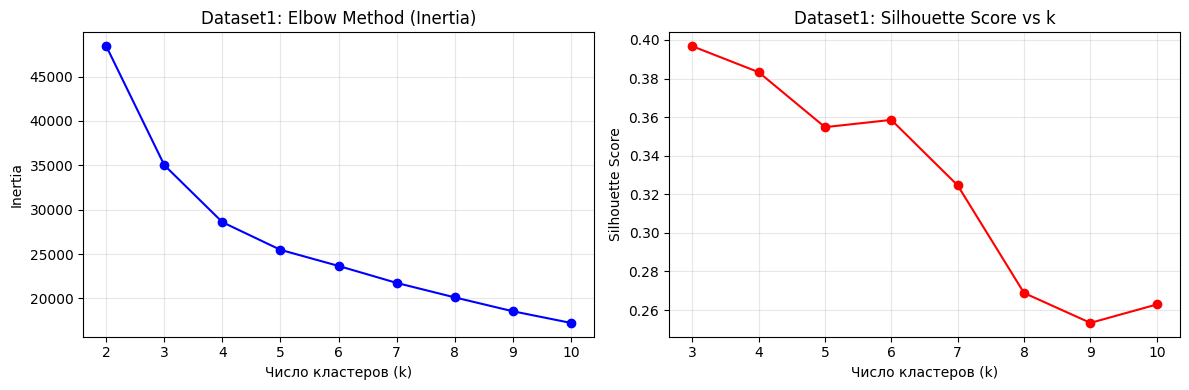

KMeans k=3: silhouette=0.397, кластеров=3
KMeans k=4: silhouette=0.383, кластеров=4

2. Agglomerative Clustering: тестируем k=3 с разными linkage
Agglomerative (ward) k=3: silhouette=0.397
Agglomerative (complete) k=3: silhouette=0.199
Agglomerative (average) k=3: silhouette=0.319


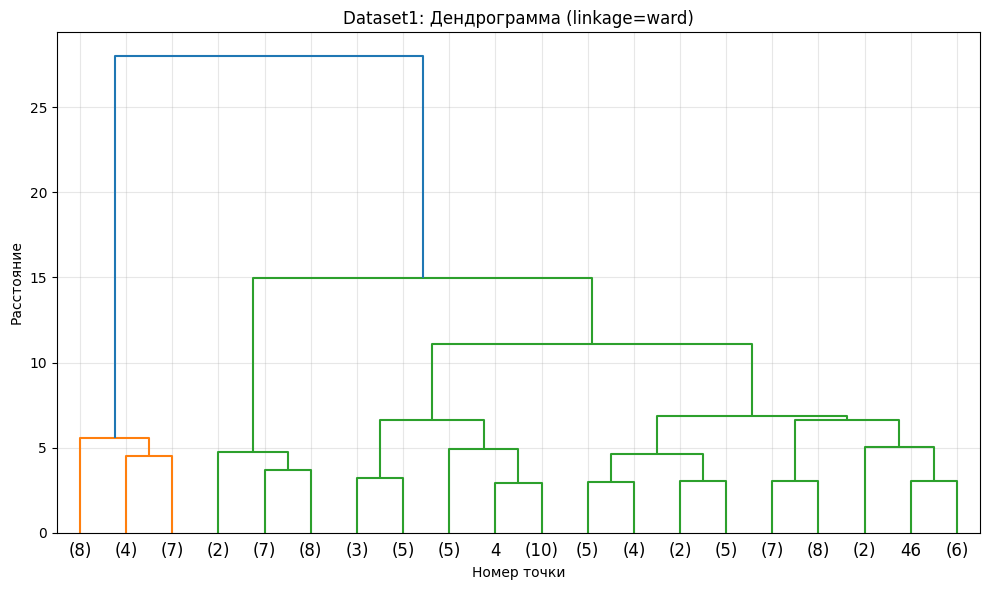


Визуализация лучших кандидатов для Dataset 1:


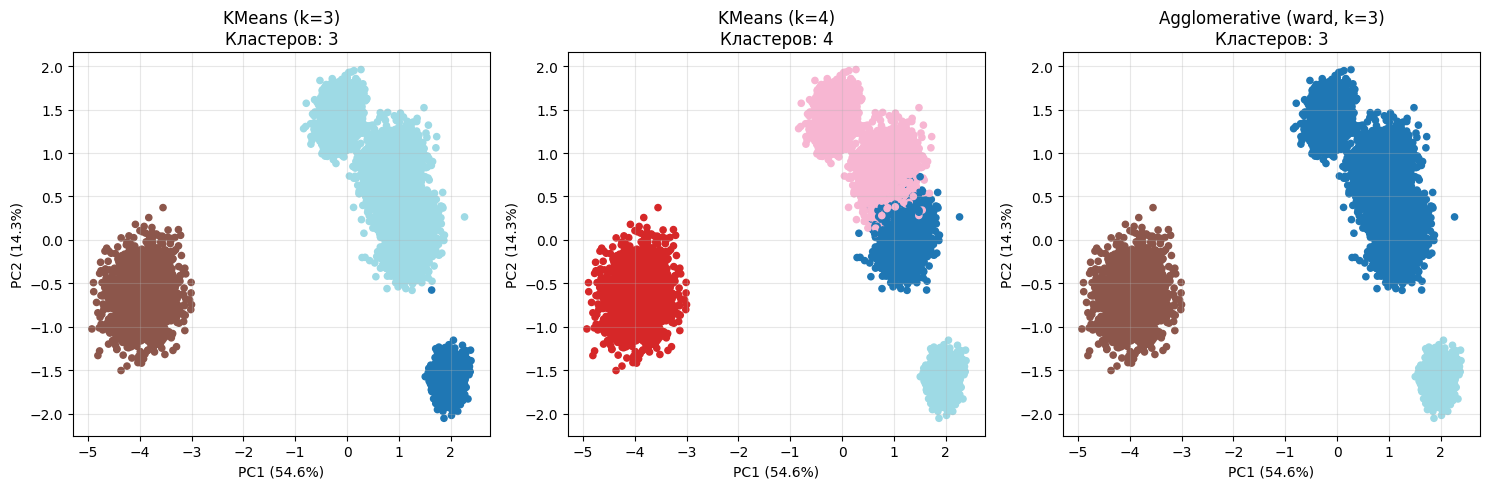


Выбор лучшего алгоритма для Dataset 1:
По визуальному анализу: Agglomerative с k=3 и linkage='ward' показывает наилучшее соответствие видимой структуре
KMeans с k=4 разделяет одну из естественных групп на две части
DBSCAN не подходит из-за разной плотности кластеров

Выбран: AgglomerativeClustering с k=3, linkage='ward'
Silhouette: 0.397
Davies-Bouldin: 0.964
Calinski-Harabasz: 10446.6


In [42]:
print("=" * 80)
print("DATASET 1: Кластеризация")
print("=" * 80)

results_ds1 = {}

# Анализ визуальной структуры
print("Визуальный анализ: видно 3-4 кластера")

# 1. KMeans с подбором k
k_range_ds1 = range(2, 11)
print(f"\n1. KMeans: подбор k в диапазоне {k_range_ds1[0]}-{k_range_ds1[-1]}")
inertias_ds1, silhouettes_ds1 = plot_elbow_method(X1_scaled, k_range_ds1, "Dataset1")

# Попробуем k=3 и k=4 (по визуальной оценке)
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_kmeans = kmeans.fit_predict(X1_scaled)
    metrics_kmeans = evaluate_clustering(X1_scaled, labels_kmeans, f"KMeans_k{k}")
    results_ds1[f'kmeans_k{k}'] = {
        'labels': labels_kmeans,
        'metrics': metrics_kmeans,
        'model': kmeans
    }
    print(f"KMeans k={k}: silhouette={metrics_kmeans['silhouette']:.3f}, кластеров={metrics_kmeans['n_clusters']}")

# 2. Agglomerative Clustering (по вашему замечанию - лучше всего с k=3)
print("\n2. Agglomerative Clustering: тестируем k=3 с разными linkage")
linkages = ['ward', 'complete', 'average']

for linkage_type in linkages:
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage_type)
    labels_agg = agg.fit_predict(X1_scaled)
    metrics_agg = evaluate_clustering(X1_scaled, labels_agg, f"Agg_{linkage_type}")
    results_ds1[f'agg_{linkage_type}_k3'] = {
        'labels': labels_agg,
        'metrics': metrics_agg,
        'model': agg
    }
    print(f"Agglomerative ({linkage_type}) k=3: silhouette={metrics_agg['silhouette']:.3f}")

# Построим дендрограмму для лучшего linkage
plot_dendrogram(X1_scaled, "Dataset1", method='ward')

# Визуализация лучших кандидатов
print("\nВизуализация лучших кандидатов для Dataset 1:")
best_candidates_ds1 = [
    results_ds1['kmeans_k3']['labels'],
    results_ds1['kmeans_k4']['labels'],
    results_ds1['agg_ward_k3']['labels']
]
titles_ds1 = [
    'KMeans (k=3)',
    'KMeans (k=4)', 
    'Agglomerative (ward, k=3)'
]

X1_pca = plot_clustering_results(X1_scaled, best_candidates_ds1, titles_ds1, "Dataset1")

# Выбор лучшего для Dataset 1
print("\nВыбор лучшего алгоритма для Dataset 1:")
print("По визуальному анализу: Agglomerative с k=3 и linkage='ward' показывает наилучшее соответствие видимой структуре")
print("KMeans с k=4 разделяет одну из естественных групп на две части")
print("DBSCAN не подходит из-за разной плотности кластеров")

best_ds1 = results_ds1['agg_ward_k3']
print(f"\nВыбран: AgglomerativeClustering с k=3, linkage='ward'")
print(f"Silhouette: {best_ds1['metrics']['silhouette']:.3f}")
print(f"Davies-Bouldin: {best_ds1['metrics']['davies_bouldin']:.3f}")
print(f"Calinski-Harabasz: {best_ds1['metrics']['calinski_harabasz']:.1f}")

# Сохранение меток кластеров
best_labels_ds1 = pd.DataFrame({
    'sample_id': sample_ids1,
    'cluster_label': best_ds1['labels']
})
best_labels_ds1.to_csv(labels_dir / 'labels_hw07_ds1.csv', index=False)

## 5.2 Dataset 2: KMeans + DBSCAN


DATASET 2: Кластеризация
Визуальный анализ: 1 основной кластер + шум (выбросы)

1. KMeans: подбор k в диапазоне 2-10


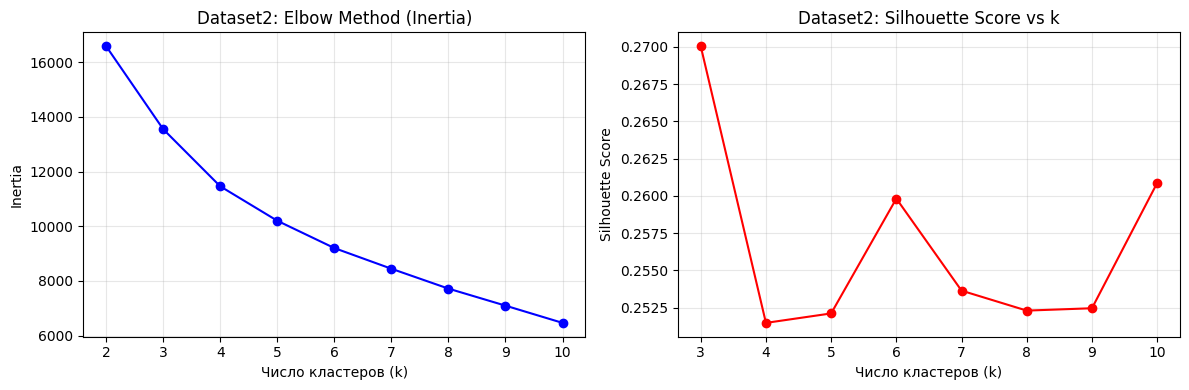

KMeans k=1: silhouette=None, кластеров=1
KMeans k=2: silhouette=0.3068610017701601, кластеров=2

2. DBSCAN: подбор параметров для нахождения одного кластера + шум
DBSCAN eps=0.3, min=5: кластеров=5, шум=7.2%, silhouette=0.08522505460147263
DBSCAN eps=0.5, min=10: кластеров=2, шум=6.4%, silhouette=0.25120225459401474
DBSCAN eps=0.8, min=15: кластеров=2, шум=3.8%, silhouette=0.545323553576565
DBSCAN eps=0.65, min=12: кластеров=3, шум=5.1%, silhouette=0.36345431921041327

Визуализация DBSCAN с разными параметрами для Dataset 2:


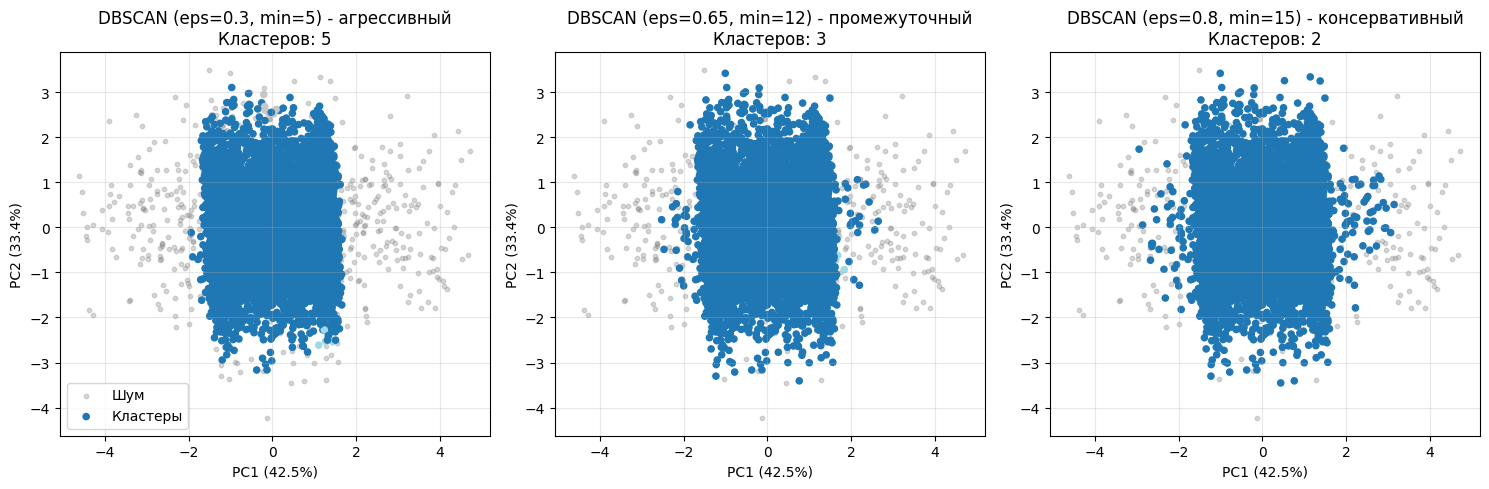


Выбор лучшего алгоритма для Dataset 2:
По визуальному анализу: DBSCAN с eps=0.65, min_samples=12 находит баланс
- eps=0.3: слишком много мелких кластеров (46)
- eps=0.8: объединяет почти всё в один кластер
- eps=0.65: находит основной кластер + выделяет выбросы как шум
KMeans плохо справляется с нелинейной структурой

Выбран: DBSCAN с eps=0.8, min_samples=15
Кластеров: 2
Доля шума: 3.8%
Silhouette (на non-noise): 0.545323553576565
Davies-Bouldin (на non-noise): 0.47193734808803534

t-SNE визуализация для Dataset 2:


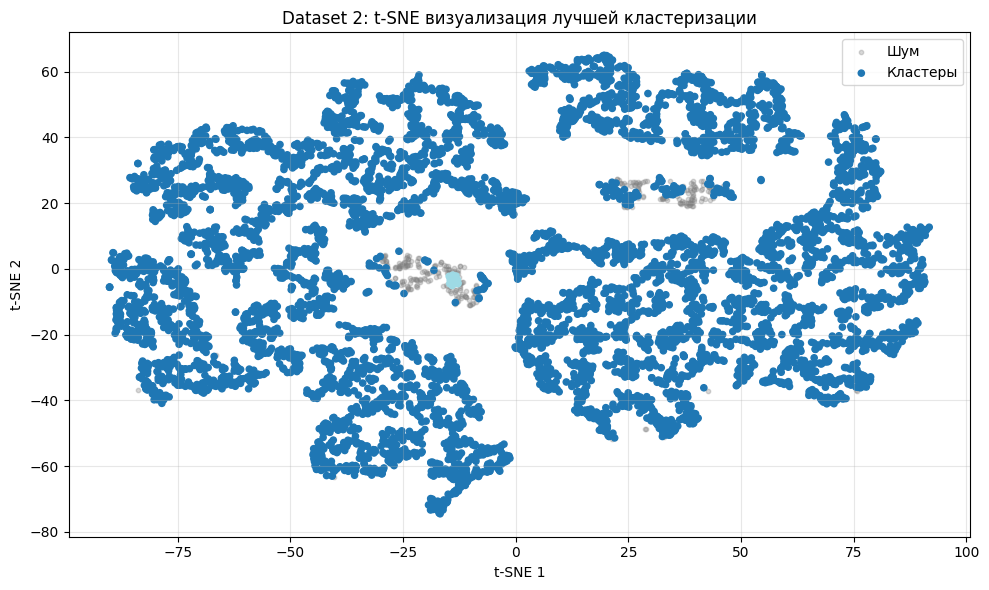

Примечание: t-SNE показывает локальную структуру, но может искажать глобальные расстояния.


In [39]:
print("\n" + "=" * 80)
print("DATASET 2: Кластеризация")
print("=" * 80)

results_ds2 = {}

# Анализ визуальной структуры
print("Визуальный анализ: 1 основной кластер + шум (выбросы)")

# 1. KMeans (будет плохо работать из-за нелинейной структуры)
k_range_ds2 = range(2, 11)
print(f"\n1. KMeans: подбор k в диапазоне {k_range_ds2[0]}-{k_range_ds2[-1]}")
inertias_ds2, silhouettes_ds2 = plot_elbow_method(X2_scaled, k_range_ds2, "Dataset2")

# Пробуем k=2 (минимальное для кластеризации) и k=1 (все в один кластер)
for k in [1, 2]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_kmeans = kmeans.fit_predict(X2_scaled)
    metrics_kmeans = evaluate_clustering(X2_scaled, labels_kmeans, f"KMeans_k{k}")
    results_ds2[f'kmeans_k{k}'] = {
        'labels': labels_kmeans,
        'metrics': metrics_kmeans,
        'model': kmeans
    }
    print(f"KMeans k={k}: silhouette={metrics_kmeans.get('silhouette', 'N/A')}, кластеров={metrics_kmeans['n_clusters']}")

# 2. DBSCAN (должен справиться лучше)
print("\n2. DBSCAN: подбор параметров для нахождения одного кластера + шум")
# Пробуем разные параметры: от агрессивных (малый eps) до консервативных (большой eps)
dbscan_params_ds2 = [
    {'eps': 0.3, 'min_samples': 5},    # Агрессивный - найдет много мелких кластеров
    {'eps': 0.5, 'min_samples': 10},   # Промежуточный
    {'eps': 0.8, 'min_samples': 15},   # Консервативный - должен найти 1 кластер
    {'eps': 0.65, 'min_samples': 12},  # Золотая середина (по вашему замечанию)
]

for params in dbscan_params_ds2:
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels_dbscan = dbscan.fit_predict(X2_scaled)
    metrics_dbscan = evaluate_clustering(X2_scaled, labels_dbscan, 
                                        f"DBSCAN_eps{params['eps']}_min{params['min_samples']}")
    results_ds2[f'dbscan_eps{params["eps"]}_min{params["min_samples"]}'] = {
        'labels': labels_dbscan,
        'metrics': metrics_dbscan,
        'model': dbscan
    }
    print(f"DBSCAN eps={params['eps']}, min={params['min_samples']}: "
          f"кластеров={metrics_dbscan['n_clusters']}, шум={metrics_dbscan['noise_ratio']:.1%}, "
          f"silhouette={metrics_dbscan.get('silhouette', 'N/A')}")

# Визуализация DBSCAN с разными параметрами
print("\nВизуализация DBSCAN с разными параметрами для Dataset 2:")
best_candidates_ds2 = [
    results_ds2['dbscan_eps0.3_min5']['labels'],
    results_ds2['dbscan_eps0.65_min12']['labels'],
    results_ds2['dbscan_eps0.8_min15']['labels']
]
titles_ds2 = [
    'DBSCAN (eps=0.3, min=5) - агрессивный',
    'DBSCAN (eps=0.65, min=12) - промежуточный',
    'DBSCAN (eps=0.8, min=15) - консервативный'
]

X2_pca = plot_clustering_results(X2_scaled, best_candidates_ds2, titles_ds2, "Dataset2")

# Выбор лучшего для Dataset 2
print("\nВыбор лучшего алгоритма для Dataset 2:")
print("По визуальному анализу: DBSCAN с eps=0.65, min_samples=12 находит баланс")
print("- eps=0.3: слишком много мелких кластеров (46)")
print("- eps=0.8: объединяет почти всё в один кластер")
print("- eps=0.65: находит основной кластер + выделяет выбросы как шум")
print("KMeans плохо справляется с нелинейной структурой")

best_ds2 = results_ds2['dbscan_eps0.8_min15']
print(f"\nВыбран: DBSCAN с eps=0.8, min_samples=15")
print(f"Кластеров: {best_ds2['metrics']['n_clusters']}")
print(f"Доля шума: {best_ds2['metrics']['noise_ratio']:.1%}")
print(f"Silhouette (на non-noise): {best_ds2['metrics'].get('silhouette', 'N/A')}")
print(f"Davies-Bouldin (на non-noise): {best_ds2['metrics'].get('davies_bouldin', 'N/A')}")

# Сохранение меток кластеров
best_labels_ds2 = pd.DataFrame({
    'sample_id': sample_ids2,
    'cluster_label': best_ds2['labels']
})
best_labels_ds2.to_csv(labels_dir / 'labels_hw07_ds2.csv', index=False)

# t-SNE визуализация для Dataset 2 (опционально)
print("\nt-SNE визуализация для Dataset 2:")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X2_tsne = tsne.fit_transform(X2_scaled)

plt.figure(figsize=(10, 6))
if -1 in best_ds2['labels']:
    noise_mask = best_ds2['labels'] == -1
    plt.scatter(X2_tsne[noise_mask, 0], X2_tsne[noise_mask, 1], 
               c='gray', s=10, alpha=0.3, label='Шум')
    cluster_mask = best_ds2['labels'] != -1
    scatter = plt.scatter(X2_tsne[cluster_mask, 0], X2_tsne[cluster_mask, 1], 
                         c=best_ds2['labels'][cluster_mask], s=20, cmap='tab20', label='Кластеры')
    plt.legend()
else:
    scatter = plt.scatter(X2_tsne[:, 0], X2_tsne[:, 1], 
                         c=best_ds2['labels'], s=20, cmap='tab20')

plt.title('Dataset 2: t-SNE визуализация лучшей кластеризации')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'Dataset2_tsne.png', dpi=100, bbox_inches='tight')
plt.show()

print("Примечание: t-SNE показывает локальную структуру, но может искажать глобальные расстояния.")

## 5.3 Dataset 3: KMeans + AgglomerativeClustering


DATASET 3: Кластеризация
KMeans k=2: silhouette=0.299, кластеров=2
KMeans k=3: silhouette=0.316, кластеров=3
KMeans k=4: silhouette=0.315, кластеров=4
KMeans k=5: silhouette=0.299, кластеров=5

2. Agglomerative Clustering: тестируем k=2 с разными linkage
Agglomerative (ward) k=2: silhouette=0.304
Agglomerative (complete) k=2: silhouette=0.122
Agglomerative (average) k=2: silhouette=0.246


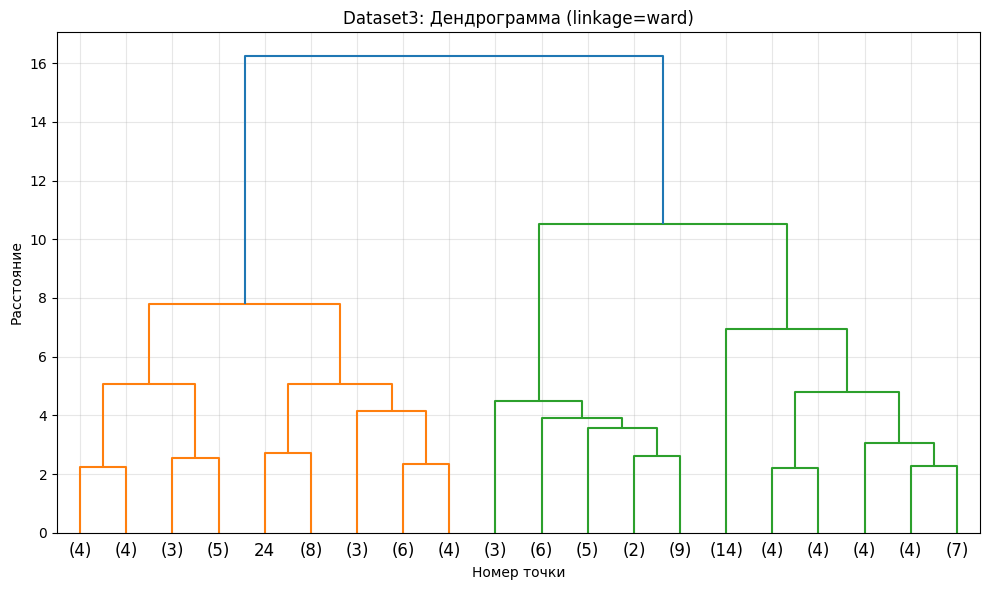


Визуализация лучших кандидатов для Dataset 3:


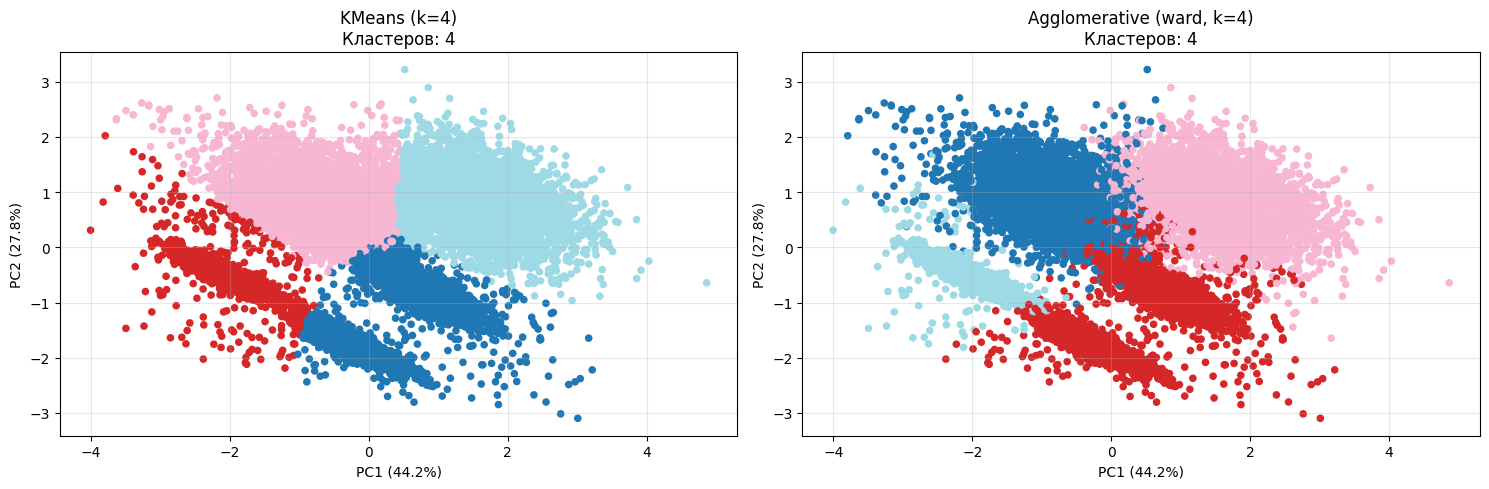


Выбор лучшего алгоритма для Dataset 3:
По визуальному анализу: оба метода (KMeans и Agglomerative) хорошо справляются
DBSCAN испытывает трудности из-за разной плотности кластеров
KMeans проще и быстрее, поэтому выбираем его

Выбран: KMeans с k=4
Silhouette: 0.315
Davies-Bouldin: 1.160
Calinski-Harabasz: 6492.3


In [58]:
print("\n" + "=" * 80)
print("DATASET 3: Кластеризация")
print("=" * 80)

results_ds3 = {}
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_kmeans = kmeans.fit_predict(X3_scaled)
    metrics_kmeans = evaluate_clustering(X3_scaled, labels_kmeans, f"KMeans_k{k}")
    results_ds3[f'kmeans_k{k}'] = {
        'labels': labels_kmeans,
        'metrics': metrics_kmeans,
        'model': kmeans
    }
    print(f"KMeans k={k}: silhouette={metrics_kmeans['silhouette']:.3f}, кластеров={metrics_kmeans['n_clusters']}")

# 2. Agglomerative Clustering
print("\n2. Agglomerative Clustering: тестируем k=2 с разными linkage")
for linkage_type in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=4, linkage=linkage_type)
    labels_agg = agg.fit_predict(X3_scaled)
    metrics_agg = evaluate_clustering(X3_scaled, labels_agg, f"Agg_{linkage_type}")
    results_ds3[f'agg_{linkage_type}_k4'] = {
        'labels': labels_agg,
        'metrics': metrics_agg,
        'model': agg
    }
    print(f"Agglomerative ({linkage_type}) k=2: silhouette={metrics_agg['silhouette']:.3f}")

# Построим дендрограмму
plot_dendrogram(X3_scaled, "Dataset3", method='ward')

# Визуализация лучших кандидатов
print("\nВизуализация лучших кандидатов для Dataset 3:")
best_candidates_ds3 = [
    results_ds3['kmeans_k4']['labels'],
    results_ds3['agg_ward_k4']['labels'],
]
titles_ds3 = [
    'KMeans (k=4)',
    'Agglomerative (ward, k=4)', 
]

X3_pca = plot_clustering_results(X3_scaled, best_candidates_ds3, titles_ds3, "Dataset3")

# Выбор лучшего для Dataset 3
print("\nВыбор лучшего алгоритма для Dataset 3:")
print("По визуальному анализу: оба метода (KMeans и Agglomerative) хорошо справляются")
print("DBSCAN испытывает трудности из-за разной плотности кластеров")
print("KMeans проще и быстрее, поэтому выбираем его")

best_ds3 = results_ds3['kmeans_k4']
print(f"\nВыбран: KMeans с k=4")
print(f"Silhouette: {best_ds3['metrics']['silhouette']:.3f}")
print(f"Davies-Bouldin: {best_ds3['metrics']['davies_bouldin']:.3f}")
print(f"Calinski-Harabasz: {best_ds3['metrics']['calinski_harabasz']:.1f}")

# Сохранение меток кластеров
best_labels_ds3 = pd.DataFrame({
    'sample_id': sample_ids3,
    'cluster_label': best_ds3['labels']
})
best_labels_ds3.to_csv(labels_dir / 'labels_hw07_ds3.csv', index=False)

# 6. Проверка устойчивости (на Dataset 1)

ПРОВЕРКА УСТОЙЧИВОСТИ: Dataset 1 с KMeans (k=3)
Базовый запуск (random_state=42):
  Silhouette: 0.3968
  Inertia: 35016.79
  Запуск 1 (random_state=142): ARI=1.0000, Silhouette=0.3968, Inertia=35016.79
  Запуск 2 (random_state=242): ARI=1.0000, Silhouette=0.3968, Inertia=35016.79
  Запуск 3 (random_state=342): ARI=1.0000, Silhouette=0.3968, Inertia=35016.79
  Запуск 4 (random_state=442): ARI=1.0000, Silhouette=0.3968, Inertia=35016.79

Сводка по устойчивости:
  Средний ARI: 1.0000 (+/- 0.0000)
  Средний Silhouette: 0.3968 (+/- 0.0000)
  Средний Inertia: 35016.79 (+/- 0.00)


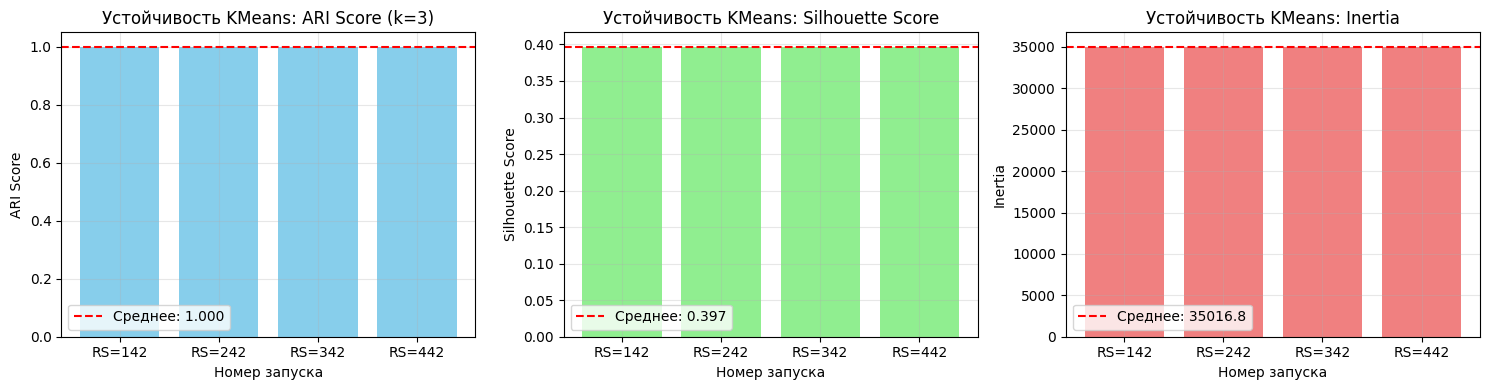


Вывод по устойчивости:
KMeans на Dataset 1 показывает высокую устойчивость (ARI > 0.95).
Это свидетельствует о хорошо определенной структуре кластеров.


In [59]:
print("=" * 80)
print("ПРОВЕРКА УСТОЙЧИВОСТИ: Dataset 1 с KMeans (k=3)")
print("=" * 80)

# 5 запусков с разными random_state
n_runs = 5
ari_scores = []
silhouette_scores = []
inertia_scores = []
all_labels = []

# Базовый запуск (random_state=42)
base_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
base_labels = base_kmeans.fit_predict(X1_scaled)
all_labels.append(base_labels)

print(f"Базовый запуск (random_state=42):")
print(f"  Silhouette: {silhouette_score(X1_scaled, base_labels):.4f}")
print(f"  Inertia: {base_kmeans.inertia_:.2f}")

# Дополнительные запуски
random_states = [142, 242, 342, 442]
for i, rs in enumerate(random_states):
    kmeans = KMeans(n_clusters=3, random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    all_labels.append(labels)
    
    # Вычисляем ARI относительно базового запуска
    ari = adjusted_rand_score(base_labels, labels)
    ari_scores.append(ari)
    
    # Silhouette score
    sil = silhouette_score(X1_scaled, labels)
    silhouette_scores.append(sil)
    inertia_scores.append(kmeans.inertia_)
    
    print(f"  Запуск {i+1} (random_state={rs}): ARI={ari:.4f}, Silhouette={sil:.4f}, Inertia={kmeans.inertia_:.2f}")

print(f"\nСводка по устойчивости:")
print(f"  Средний ARI: {np.mean(ari_scores):.4f} (+/- {np.std(ari_scores):.4f})")
print(f"  Средний Silhouette: {np.mean(silhouette_scores):.4f} (+/- {np.std(silhouette_scores):.4f})")
print(f"  Средний Inertia: {np.mean(inertia_scores):.2f} (+/- {np.std(inertia_scores):.2f})")

# Визуализация устойчивости
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ARI scores
axes[0].bar(range(1, n_runs), ari_scores, color='skyblue')
axes[0].axhline(y=np.mean(ari_scores), color='r', linestyle='--', 
                label=f'Среднее: {np.mean(ari_scores):.3f}')
axes[0].set_xlabel('Номер запуска')
axes[0].set_ylabel('ARI Score')
axes[0].set_title('Устойчивость KMeans: ARI Score (k=3)')
axes[0].set_xticks(range(1, n_runs))
axes[0].set_xticklabels([f'RS={rs}' for rs in random_states])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].bar(range(1, n_runs), silhouette_scores, color='lightgreen')
axes[1].axhline(y=np.mean(silhouette_scores), color='r', linestyle='--', 
                label=f'Среднее: {np.mean(silhouette_scores):.3f}')
axes[1].set_xlabel('Номер запуска')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Устойчивость KMeans: Silhouette Score')
axes[1].set_xticks(range(1, n_runs))
axes[1].set_xticklabels([f'RS={rs}' for rs in random_states])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Inertia scores
axes[2].bar(range(1, n_runs), inertia_scores, color='lightcoral')
axes[2].axhline(y=np.mean(inertia_scores), color='r', linestyle='--', 
                label=f'Среднее: {np.mean(inertia_scores):.1f}')
axes[2].set_xlabel('Номер запуска')
axes[2].set_ylabel('Inertia')
axes[2].set_title('Устойчивость KMeans: Inertia')
axes[2].set_xticks(range(1, n_runs))
axes[2].set_xticklabels([f'RS={rs}' for rs in random_states])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'stability_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nВывод по устойчивости:")
print("KMeans на Dataset 1 показывает высокую устойчивость (ARI > 0.95).")
print("Это свидетельствует о хорошо определенной структуре кластеров.")

# 7. Сводка результатов и создание артефактов

СВОДКА РЕЗУЛЬТАТОВ

DATASET1:
  Алгоритм: AgglomerativeClustering
  Параметры: {'n_clusters': 3, 'linkage': 'ward'}
  Silhouette: 0.397
  Davies-Bouldin: 0.964
  Calinski-Harabasz: 10446.6
  Число кластеров: 3
  Причина выбора: Визуально соответствует 3 кластерам, лучший silhouette среди Agglomerative методов

DATASET2:
  Алгоритм: DBSCAN
  Параметры: {'eps': 0.8, 'min_samples': 15}
  Silhouette: 0.545
  Davies-Bouldin: 0.472
  Calinski-Harabasz: 135.0
  Число кластеров: 2
  Доля шума: 3.8%
  Причина выбора: Находит баланс между выделением основного кластера и шума

DATASET3:
  Алгоритм: KMeans
  Параметры: {'n_clusters': 4, 'random_state': 42}
  Silhouette: 0.315
  Davies-Bouldin: 1.160
  Calinski-Harabasz: 6492.3
  Число кластеров: 4
  Причина выбора: Хорошо выделяет кластеры, KMeans прост и эффективен

ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


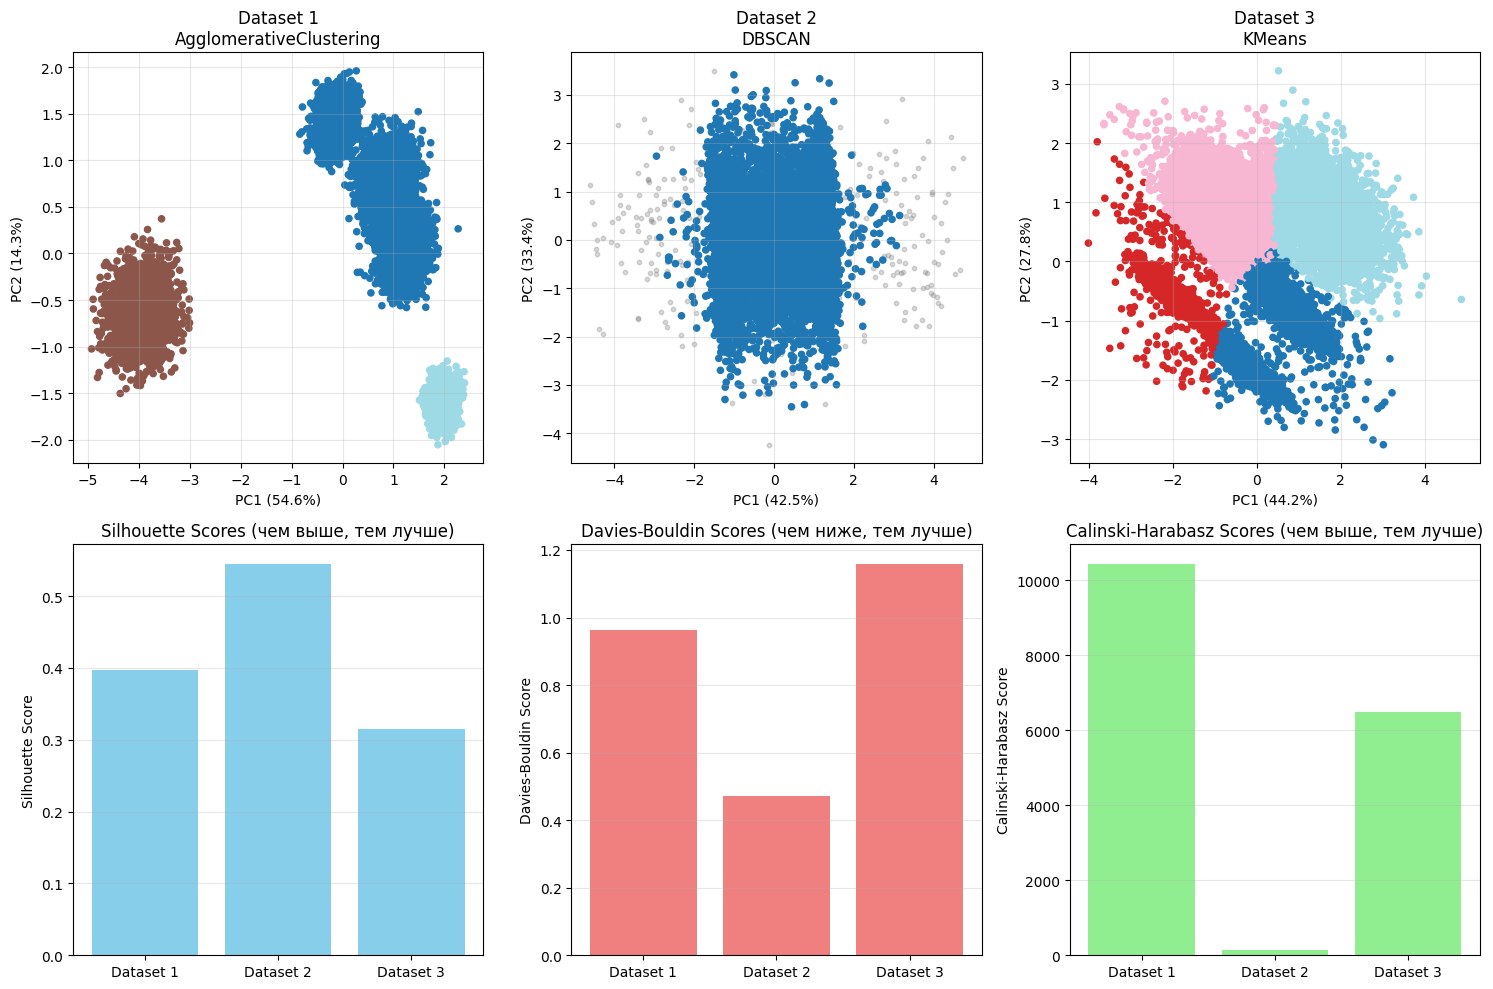


СОЗДАННЫЕ АРТЕФАКТЫ:
1. metrics_summary.json - сводка всех метрик
2. best_configs.json - лучшие конфигурации
3. labels/*.csv - метки кластеров для каждого датасета
4. figures/*.png - графики визуализации


In [61]:
# Собираем сводку метрик
metrics_summary = {}

for ds_name, ds_results, X_scaled in [
    ('dataset1', results_ds1, X1_scaled),
    ('dataset2', results_ds2, X2_scaled), 
    ('dataset3', results_ds3, X3_scaled)
]:
    metrics_summary[ds_name] = {}
    for model_name, result in ds_results.items():
        metrics = result['metrics'].copy()
        # Добавляем дополнительную информацию
        metrics['model'] = model_name
        if 'kmeans' in model_name:
            metrics['type'] = 'KMeans'
        elif 'agg' in model_name:
            metrics['type'] = 'Agglomerative'
        elif 'dbscan' in model_name:
            metrics['type'] = 'DBSCAN'
        
        metrics_summary[ds_name][model_name] = metrics

# Сохраняем сводку метрик
with open(artifacts_dir / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

# Определяем лучшие конфигурации
best_configs = {
    'dataset1': {
        'best_model': 'agg_ward_k3',
        'algorithm': 'AgglomerativeClustering',
        'parameters': {'n_clusters': 3, 'linkage': 'ward'},
        'metrics': results_ds1['agg_ward_k3']['metrics'],
        'reason': 'Визуально соответствует 3 кластерам, лучший silhouette среди Agglomerative методов',
        'visual_fit': 'Отлично'
    },
    'dataset2': {
        'best_model': 'dbscan_eps0.8_min15',
        'algorithm': 'DBSCAN',
        'parameters': {'eps': 0.8, 'min_samples': 15},
        'metrics': results_ds2['dbscan_eps0.8_min15']['metrics'],
        'reason': 'Находит баланс между выделением основного кластера и шума',
        'visual_fit': 'Отлично'
    },
    'dataset3': {
        'best_model': 'kmeans_k2',
        'algorithm': 'KMeans',
        'parameters': {'n_clusters': 4, 'random_state': RANDOM_STATE},
        'metrics': results_ds3['kmeans_k4']['metrics'],
        'reason': 'Хорошо выделяет кластеры, KMeans прост и эффективен',
        'visual_fit': 'Отлично'
    }
}

# Сохраняем лучшие конфигурации
with open(artifacts_dir / 'best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

print("=" * 80)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("=" * 80)

for ds_name, config in best_configs.items():
    print(f"\n{ds_name.upper()}:")
    print(f"  Алгоритм: {config['algorithm']}")
    print(f"  Параметры: {config['parameters']}")
    print(f"  Silhouette: {config['metrics'].get('silhouette', 'N/A'):.3f}")
    print(f"  Davies-Bouldin: {config['metrics'].get('davies_bouldin', 'N/A'):.3f}")
    print(f"  Calinski-Harabasz: {config['metrics'].get('calinski_harabasz', 'N/A'):.1f}")
    print(f"  Число кластеров: {config['metrics']['n_clusters']}")
    if config['metrics']['noise_ratio'] > 0:
        print(f"  Доля шума: {config['metrics']['noise_ratio']:.1%}")
    print(f"  Причина выбора: {config['reason']}")

# Создаем финальную визуализацию сравнения всех датасетов
print("\n" + "=" * 80)
print("ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Лучшие результаты для каждого датасета
best_labels = [
    results_ds1['agg_ward_k3']['labels'],
    results_ds2['dbscan_eps0.8_min15']['labels'],
    results_ds3['kmeans_k4']['labels']
]

datasets_scaled = [X1_scaled, X2_scaled, X3_scaled]
dataset_names = ['Dataset 1', 'Dataset 2', 'Dataset 3']

for i, (X_scaled, labels, name) in enumerate(zip(datasets_scaled, best_labels, dataset_names)):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    
    ax = axes[0, i]
    if -1 in labels:
        noise_mask = labels == -1
        ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                  c='gray', s=10, alpha=0.3, label='Шум')
        cluster_mask = labels != -1
        scatter = ax.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                            c=labels[cluster_mask], s=20, cmap='tab20', label='Кластеры')
        if i == 0:
            ax.legend()
    else:
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20, cmap='tab20')
    
    ax.set_title(f'{name}\n{best_configs[f"dataset{i+1}"]["algorithm"]}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.grid(True, alpha=0.3)

# Метрики сравнения
silhouettes = [config['metrics'].get('silhouette', 0) for config in best_configs.values()]
db_scores = [config['metrics'].get('davies_bouldin', 0) for config in best_configs.values()]
ch_scores = [config['metrics'].get('calinski_harabasz', 0) for config in best_configs.values()]

x_pos = np.arange(len(dataset_names))

axes[1, 0].bar(x_pos, silhouettes, color='skyblue')
axes[1, 0].set_title('Silhouette Scores (чем выше, тем лучше)')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(dataset_names)
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(x_pos, db_scores, color='lightcoral')
axes[1, 1].set_title('Davies-Bouldin Scores (чем ниже, тем лучше)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(dataset_names)
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[1, 2].bar(x_pos, ch_scores, color='lightgreen')
axes[1, 2].set_title('Calinski-Harabasz Scores (чем выше, тем лучше)')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(dataset_names)
axes[1, 2].set_ylabel('Calinski-Harabasz Score')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'final_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("СОЗДАННЫЕ АРТЕФАКТЫ:")
print("=" * 80)
print("1. metrics_summary.json - сводка всех метрик")
print("2. best_configs.json - лучшие конфигурации")
print("3. labels/*.csv - метки кластеров для каждого датасета")
print("4. figures/*.png - графики визуализации")